# Customer Segmentation — Continuation

## 1. Project Overview

**Objective.** Build a customer-segmentation layer on top of the existing `mobile-recommendation-system`
project. The system already performs phone-side recommendations (see `ML Model/pipeline/` and
`ML Model/EDA_and_Feature_Engineering_to_Dataset.ipynb`). This notebook adds the *customer-side*:
given the behavioural and demographic dataset in `dataset/customer_dataset.csv`, partition customers
into stable, business-meaningful segments that downstream code (admin dashboards, marketing campaigns,
personalised recommendation defaults) can use.

**How this notebook extends the existing project.**

- It does **not** modify any file under `ML Model/`, `backend/`, or `frontend/`. It is a read-only
  analysis on top of `dataset/customer_dataset.csv` and writes only to the new folder
  `ML Model/segmentation_outputs/`.
- It reuses the same engineering style (groupwise imputation, median/mode fill, careful parsing of
  free-text JSON columns) that the existing `EDA_and_Feature_Engineering_to_Dataset.ipynb` uses — but
  adapted for customer data rather than phone specs.
- The exported cluster assignments (CSV + JSON summary) are deliberately formatted to match the
  shape of the existing `UserPreference` / `CustomerProfile` Prisma models
  (`backend/prisma/schema.prisma`), so they can be ingested by the existing backend without schema
  changes.

**Segmentation target.** The dataset has 16,608 transaction rows but only 4,557 unique
`customer_id`s (one customer can have multiple purchase events). Clustering is therefore performed
at the **customer level**: each row of the segmentation input is one customer, with their
purchase behaviour aggregated across all their events.

**Outputs produced (in `ML Model/segmentation_outputs/`):**

1. `customer_segments.csv` — every customer with their assigned `cluster_id` and human-readable
   `segment_name`.
2. `cluster_profiles.json` — per-cluster centroid, size, top brands, top categories, business
   description, suggested marketing strategy.
3. `cluster_summary.csv` — pivot table summary per cluster (mean of each numeric feature).
4. `model_artifacts/` — fitted `StandardScaler` + K-Means model (joblib) for inference reuse.

## 2. Import Libraries

Standard scientific Python stack plus scikit-learn for clustering and matplotlib / seaborn for
visualisation. No project-internal imports are required — this notebook is self-contained so the
existing `ML Model/pipeline/` package remains untouched.

In [1]:
import os
import re
import json
import ast
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import joblib

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded. Python + pandas + scikit-learn ready.")

Libraries loaded. Python + pandas + scikit-learn ready.


## 3. Load Dataset

We load from the same dataset folder the rest of the project uses, with no modifications. Display
shape, columns, dtypes, and a sample of records so the schema is explicit before we go further.

In [2]:
# Resolve project paths the same way the existing pipeline does (PROJECT_ROOT/...).
NOTEBOOK_DIR = Path(os.getcwd()).resolve()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "dataset").exists() else NOTEBOOK_DIR.parent
# The notebook is co-located with `ML Model/`, so the dataset sits one level up.
if not (PROJECT_ROOT / "dataset").exists():
    PROJECT_ROOT = NOTEBOOK_DIR.parent

DATA_PATH = PROJECT_ROOT / "dataset" / "customer_dataset.csv"
OUTPUT_DIR = NOTEBOOK_DIR / "segmentation_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "model_artifacts").mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_PATH    =", DATA_PATH)
print("OUTPUT_DIR   =", OUTPUT_DIR)

df = pd.read_csv(DATA_PATH)
print("\nShape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nDtypes:")
print(df.dtypes)

PROJECT_ROOT = F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system
DATA_PATH    = F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\dataset\customer_dataset.csv
OUTPUT_DIR   = F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs

Shape: (16608, 24)

Columns: ['customer_id', 'customer_name', 'age', 'gender', 'city', 'country', 'mobile_brand_purchased', 'mobile_model_purchased', 'purchase_date', 'purchase_amount_npr', 'payment_method', 'purchase_frequency_per_year', 'average_spend_npr', 'browsing_history', 'wishlist', 'rating', 'review', 'preferred_brand', 'preferred_category', 'accessories_purchased', 'warranty_opted', 'exchange_history', 'interaction_channel', 'last_active_at']

Dtypes:
customer_id                        str
customer_name                      str
age                              int64
gender                             str
city           

In [3]:
df.head(5)

,customer_id,customer_name,age,gender,city,country,mobile_brand_purchased,mobile_model_purchased,purchase_date,purchase_amount_npr,...,wishlist,rating,review,preferred_brand,preferred_category,accessories_purchased,warranty_opted,exchange_history,interaction_channel,last_active_at
0,CUST-000EFD69,Ankit Hamal,75,Male,Hetauda,Nepal,Apple,Apple iPhone XS,2021-07-14,96700.0,...,"[{""item"": ""Apple Apple iPhone XS"", ""added_at"":...",5,Would buy again from this brand,Apple,Battery-focused,"[{""item"": ""Earphones"", ""price_npr"": 642, ""purc...",Yes,[],Mobile App,2024-04-26 12:00:00
1,CUST-000EFD69,Ankit Hamal,75,Male,Hetauda,Nepal,Apple,Apple iPhone 17 Pro Max,2022-10-21,81300.0,...,"[{""item"": ""Apple Apple iPhone 17 Pro Max"", ""ad...",5,"Average phone, nothing special",Apple,Battery-focused,"[{""item"": ""Stylus Pen"", ""price_npr"": 1574, ""pu...",No,[],Daraz,2024-04-26 12:00:00
2,CUST-000EFD69,Ankit Hamal,75,Male,Hetauda,Nepal,Apple,Apple iPhone XS Max,2023-09-05,80900.0,...,"[{""item"": ""Apple Apple iPhone XS Max"", ""added_...",3,Could be better at this price,Apple,Battery-focused,"[{""item"": ""Camera Lens Kit"", ""price_npr"": 4217...",No,[],In-store,2024-04-26 12:00:00
3,CUST-000EFD69,Ankit Hamal,75,Male,Hetauda,Nepal,Apple,Apple iPhone 16,2024-04-26,94000.0,...,"[{""item"": ""Apple Apple iPhone 16"", ""added_at"":...",4,Heating issue during heavy use,Apple,Battery-focused,"[{""item"": ""Earphones"", ""price_npr"": 2369, ""pur...",No,[],WhatsApp,2024-04-26 12:00:00
4,CUST-00415B2B,Sandesh Limbu,58,Male,Gorkha,Nepal,Vivo,vivo iQOO Neo9S Pro+,2021-06-04,46000.0,...,"[{""item"": ""Xiaomi Xiaomi Redmi 12C"", ""added_at...",4,"Average phone, nothing special",Samsung,Gaming,"[{""item"": ""Selfie Stick"", ""price_npr"": 440, ""p...",Yes,[],Daraz,2024-03-11 12:00:00


In [4]:
print("Unique customers :", df["customer_id"].nunique())
print("Unique countries  :", df["country"].unique())
print("Unique cities     :", df["city"].nunique())
print("Date range        :", df["purchase_date"].min(), "->", df["purchase_date"].max())
print("last_active range :", df["last_active_at"].min(), "->", df["last_active_at"].max())

Unique customers : 4557
Unique countries  : <StringArray>
['Nepal']
Length: 1, dtype: str
Unique cities     : 90
Date range        : 2020-01-01 -> 2026-04-03
last_active range : 2020-05-20 12:00:00 -> 2026-04-03 12:00:00


## 4. Exploratory Data Analysis (EDA)

The dataset has no nulls in the raw CSV (every JSON / category cell is non-empty), so the missing-
value analysis focuses on *implicit* missingness: empty JSON arrays, empty exchange histories, etc.
We also surface duplicate rows, summary statistics, and the categorical distributions that will feed
the cluster feature engineering.

In [5]:
print("=== Missing values per column ===")
print(df.isna().sum())
print("\n=== Duplicate row count ===")
print("full-row duplicates      :", df.duplicated().sum())
print("customer_id duplicates   :", df.duplicated(subset=["customer_id"]).sum())
print("(transaction_id duplicates:", df.duplicated(subset=["customer_id", "purchase_date", "mobile_model_purchased"]).sum(), ")")

=== Missing values per column ===
customer_id                    0
customer_name                  0
age                            0
gender                         0
city                           0
country                        0
mobile_brand_purchased         0
mobile_model_purchased         0
purchase_date                  0
purchase_amount_npr            0
payment_method                 0
purchase_frequency_per_year    0
average_spend_npr              0
browsing_history               0
wishlist                       0
rating                         0
review                         0
preferred_brand                0
preferred_category             0
accessories_purchased          0
warranty_opted                 0
exchange_history               0
interaction_channel            0
last_active_at                 0
dtype: int64

=== Duplicate row count ===
full-row duplicates      : 0
customer_id duplicates   : 12051
(transaction_id duplicates: 0 )


In [6]:
print("=== Numeric summary statistics ===")
df.describe(include=[np.number]).T

=== Numeric summary statistics ===


,count,mean,std,min,25%,50%,75%,max
age,16608.0,47.258731,10.033284,23.0,40.0,46.0,53.0,75.0
purchase_amount_npr,16608.0,67616.046484,49590.595678,12400.0,34900.0,51500.0,83700.0,500800.0
purchase_frequency_per_year,16608.0,2.431780,1.165369,1.2,1.4,2.5,3.0,8.6
average_spend_npr,16608.0,67615.909080,42574.630341,15000.0,40600.0,55740.0,83033.0,363920.0
rating,16608.0,3.978263,1.011202,1.0,3.0,4.0,5.0,5.0


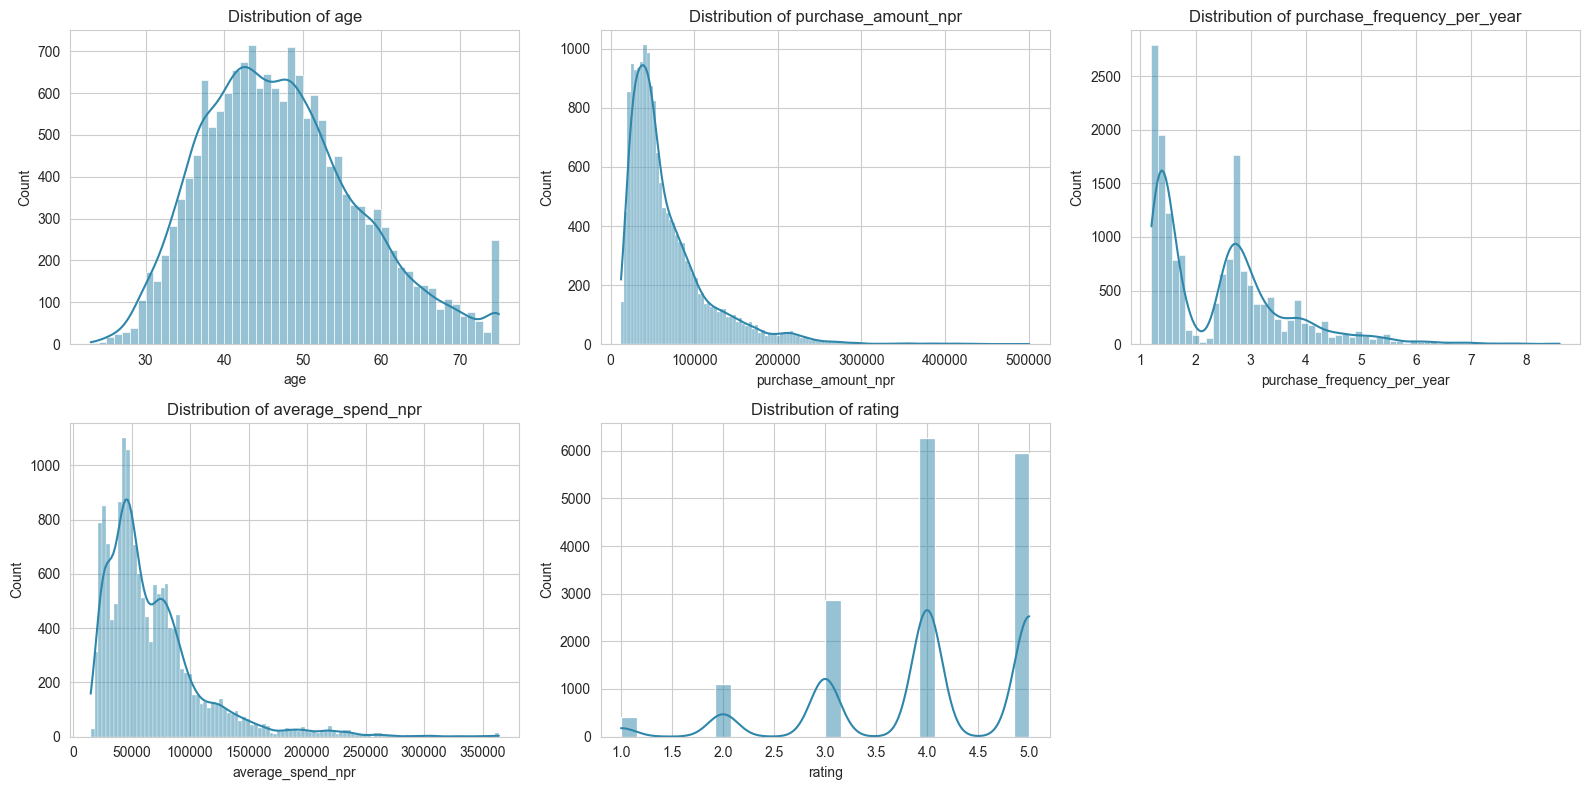

Saved: F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\numeric_distributions.png


In [7]:
# Distribution of the key numeric features that drive segmentation.
numeric_cols = ["age", "purchase_amount_npr", "purchase_frequency_per_year",
                "average_spend_npr", "rating"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#2E86AB")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
# Hide the unused 6th subplot.
axes[5].axis("off")
plt.tight_layout()
out_path = OUTPUT_DIR / "numeric_distributions.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

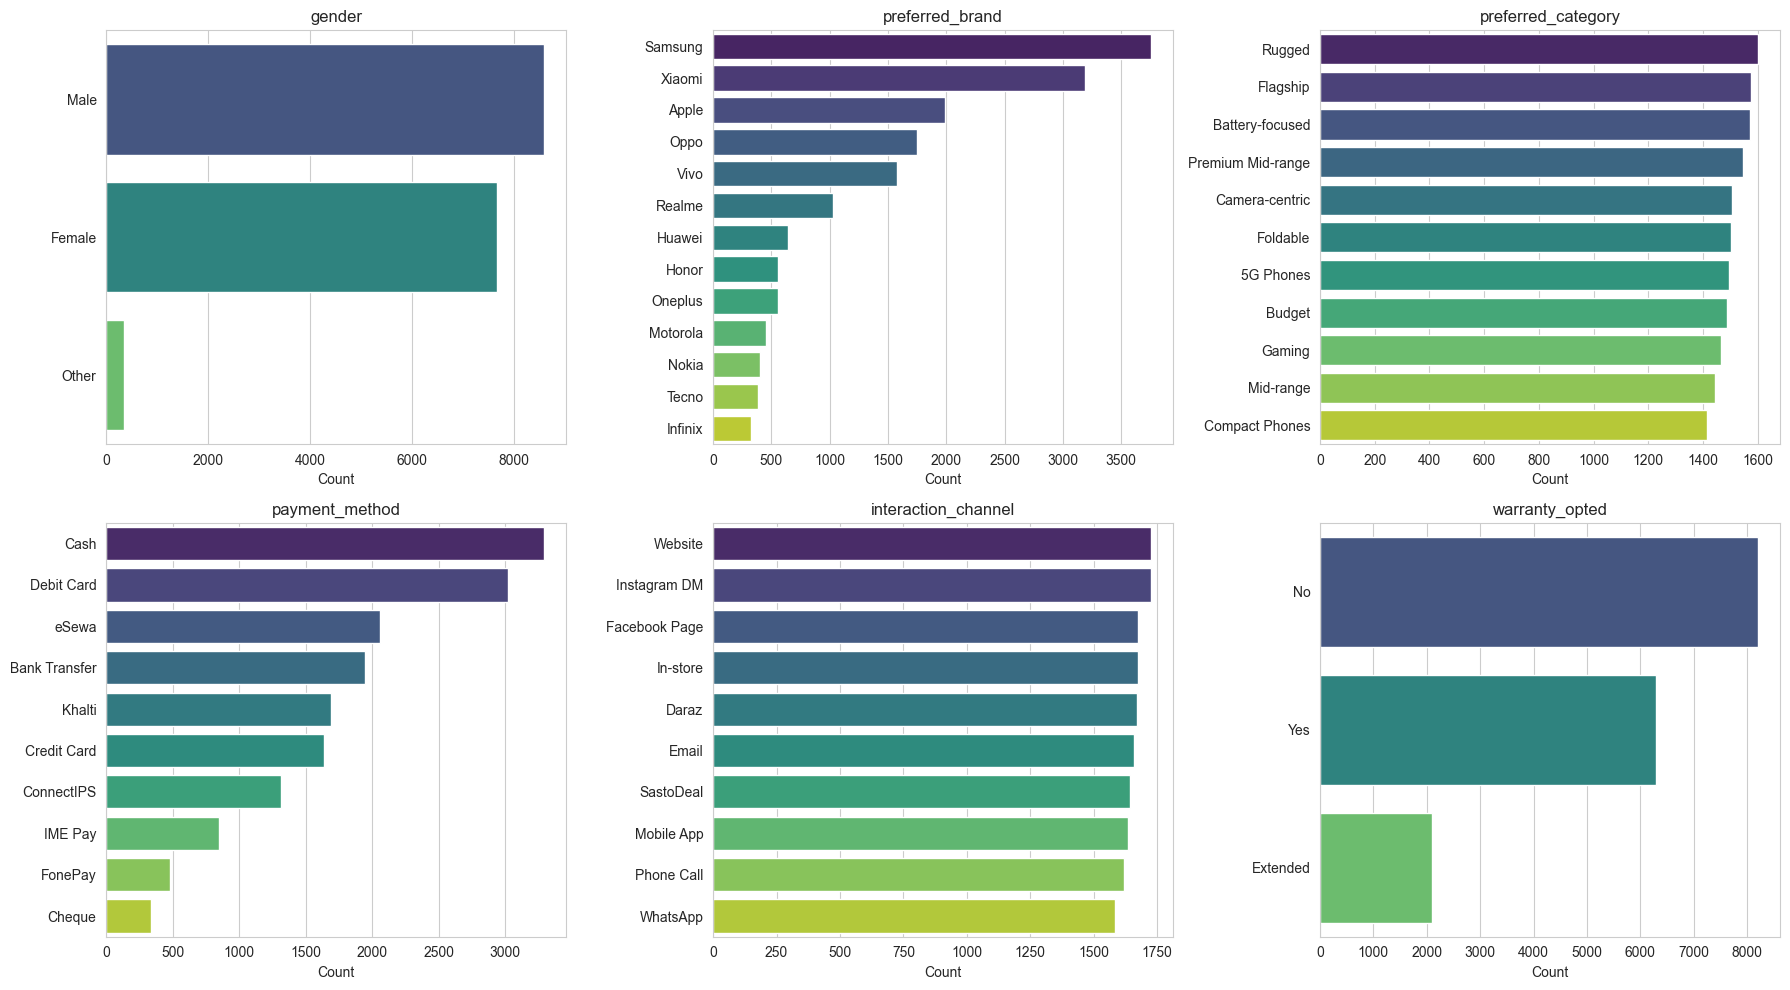

Saved: F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\categorical_distributions.png


In [8]:
# Categorical distributions: gender, preferred_brand, preferred_category, payment_method.
cat_cols = ["gender", "preferred_brand", "preferred_category",
            "payment_method", "interaction_channel", "warranty_opted"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=axes[i], palette="viridis")
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")
plt.tight_layout()
out_path = OUTPUT_DIR / "categorical_distributions.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

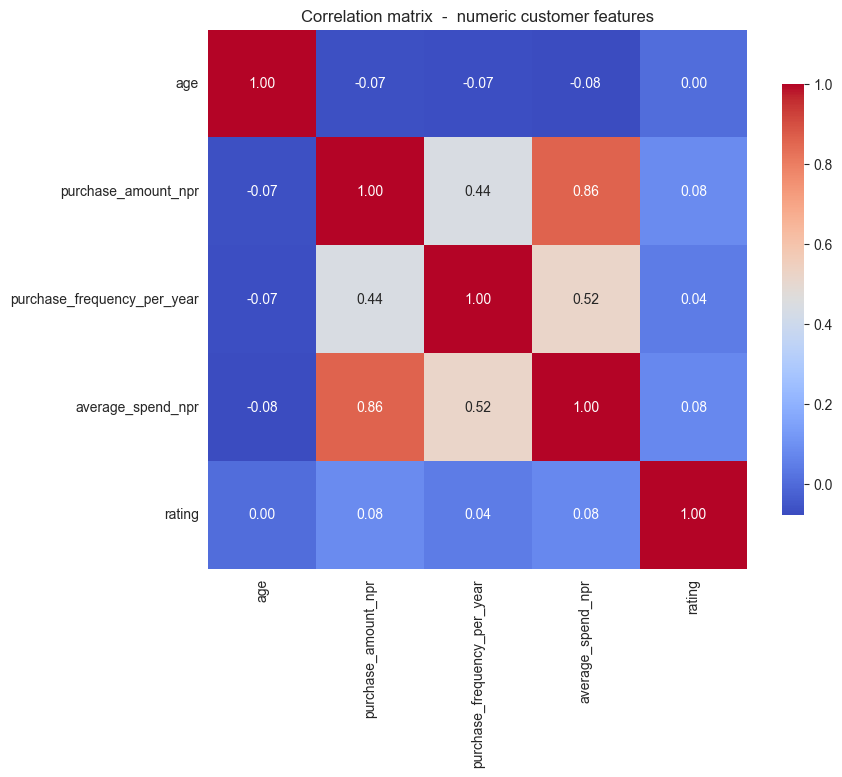

Saved: F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\correlation_heatmap.png

Correlation matrix:
                                  age  purchase_amount_npr  \
age                          1.000000            -0.066353   
purchase_amount_npr         -0.066353             1.000000   
purchase_frequency_per_year -0.069195             0.443162   
average_spend_npr           -0.077288             0.858522   
rating                       0.003724             0.084344   

                             purchase_frequency_per_year  average_spend_npr  \
age                                            -0.069195          -0.077288   
purchase_amount_npr                             0.443162           0.858522   
purchase_frequency_per_year                     1.000000           0.516191   
average_spend_npr                               0.516191           1.000000   
rating                                          0.042865        

In [9]:
# Correlation heatmap on the numeric columns.
plt.figure(figsize=(9, 7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix  -  numeric customer features")
out_path = OUTPUT_DIR / "correlation_heatmap.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print("Saved:", out_path)
print("\nCorrelation matrix:")
print(corr)

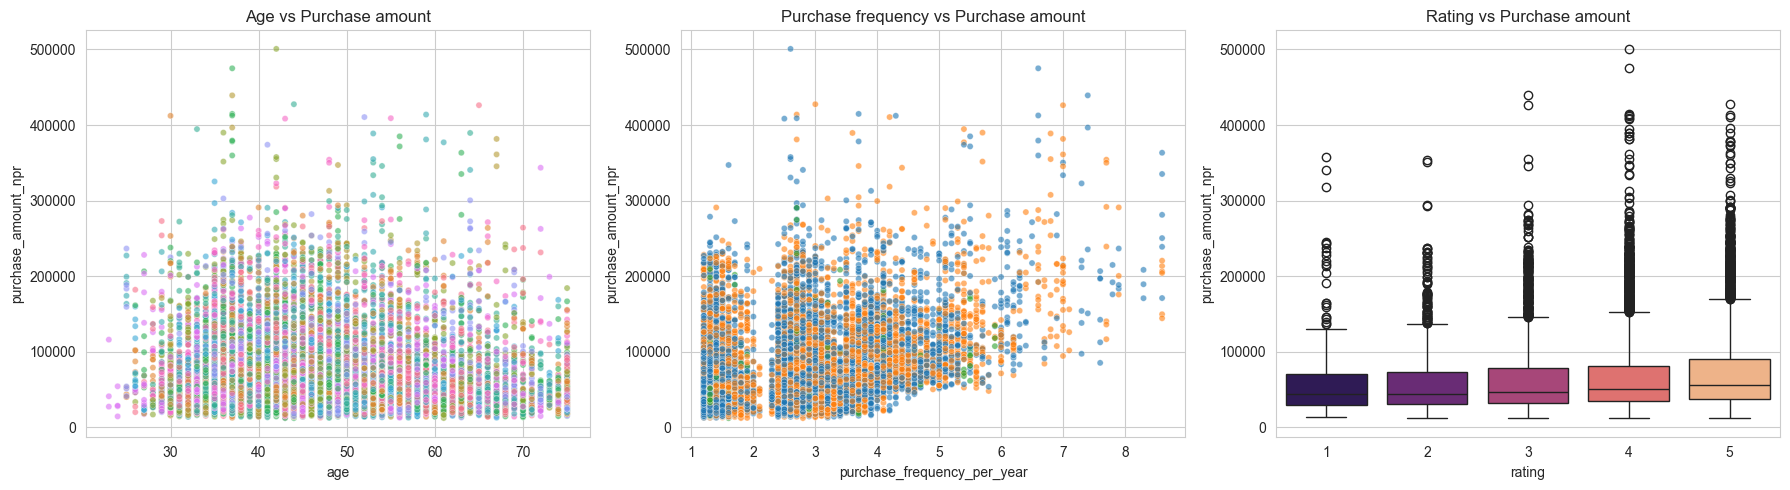

Saved: F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\feature_relationships.png


In [10]:
# Feature relationships: spend vs age, spend vs frequency, rating vs spend.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=df, x="age", y="purchase_amount_npr",
                hue="preferred_category", ax=axes[0], alpha=0.6, s=20, legend=False)
axes[0].set_title("Age vs Purchase amount")

sns.scatterplot(data=df, x="purchase_frequency_per_year", y="purchase_amount_npr",
                hue="gender", ax=axes[1], alpha=0.6, s=20, legend=False)
axes[1].set_title("Purchase frequency vs Purchase amount")

sns.boxplot(data=df, x="rating", y="purchase_amount_npr", ax=axes[2], palette="magma")
axes[2].set_title("Rating vs Purchase amount")
plt.tight_layout()
out_path = OUTPUT_DIR / "feature_relationships.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

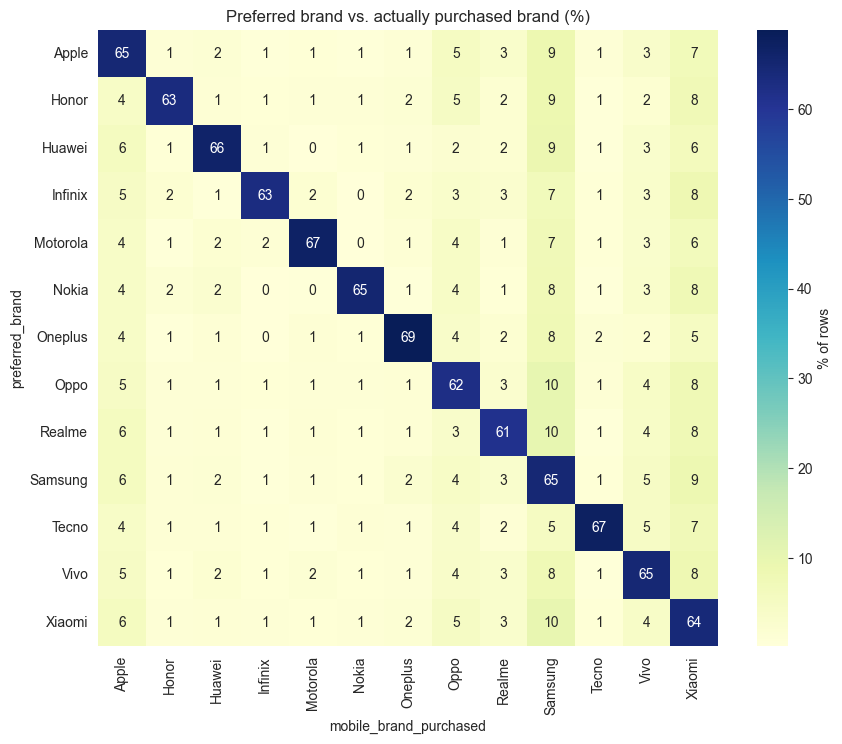

Saved: F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\brand_loyalty_heatmap.png


In [11]:
# Brand-crosstab: which brands do the brand-loyal customers actually purchase?
loyalty = pd.crosstab(df["preferred_brand"], df["mobile_brand_purchased"], normalize="index") * 100
plt.figure(figsize=(10, 8))
sns.heatmap(loyalty, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={"label": "% of rows"})
plt.title("Preferred brand vs. actually purchased brand (%)")
plt.xlabel("mobile_brand_purchased")
plt.ylabel("preferred_brand")
out_path = OUTPUT_DIR / "brand_loyalty_heatmap.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

## 5. Data Preprocessing

Goal: collapse the transaction-level data to one row per customer with engineered features that are
(a) numeric, (b) interpretable, and (c) consistent with the cleaning logic used in
`EDA_and_Feature_Engineering_to_Dataset.ipynb` (groupwise + global median fill for numerics,
groupwise mode for categoricals, free-text JSON parsed with the same literal-eval pattern the
project already uses).

Steps:

1. Parse `browsing_history`, `wishlist`, `accessories_purchased`, `exchange_history` JSON columns.
2. Aggregate to per-customer behavioural metrics.
3. Encode categoricals (one-hot) and scale numerics (z-score).
4. Outlier inspection: keep IQR-based flag column for transparency but do **not** drop — the
   long-tail is informative for segmentation (high spenders form a meaningful cluster).

In [12]:
# ------------------------------------------------------------------
# 5.1  Parse the JSON-like list/dict columns.
#     The wishlist / browsing columns use lowercase `false/true` so we
#     normalise to Python's True/False before ast.literal_eval.
# ------------------------------------------------------------------
def safe_parse_list(s, default=None):
    """Parse a JSON-array string; normalise lowercase booleans first."""
    if default is None:
        default = []
    if not isinstance(s, str) or not s.strip():
        return default
    try:
        normalised = re.sub(r"\b(false|true|null)\b",
                            lambda m: m.group(0).upper(),
                            s)
        return ast.literal_eval(normalised)
    except (ValueError, SyntaxError):
        return default


def parse_browsing(s):
    """browsing_history: list of {item, viewed_at}."""
    out = safe_parse_list(s, default=[])
    return [str(x.get("item", "")).strip() for x in out if isinstance(x, dict)]


def parse_wishlist(s):
    """wishlist: list of {item, added_at, purchased}."""
    out = safe_parse_list(s, default=[])
    items, purchased, added_dates = [], [], []
    for x in out:
        if not isinstance(x, dict):
            continue
        items.append(str(x.get("item", "")).strip())
        purchased.append(bool(x.get("purchased", False)))
        added_dates.append(x.get("added_at"))
    return items, purchased, added_dates


def parse_accessories(s):
    """accessories_purchased: list of {item, price_npr, purchased_with_phone}."""
    out = safe_parse_list(s, default=[])
    items, prices, with_phone = [], [], []
    for x in out:
        if not isinstance(x, dict):
            continue
        items.append(str(x.get("item", "")).strip())
        try:
            prices.append(float(x.get("price_npr", 0) or 0))
        except (TypeError, ValueError):
            prices.append(0.0)
        with_phone.append(bool(x.get("purchased_with_phone", False)))
    return items, prices, with_phone


def parse_exchange(s):
    """exchange_history: list of dicts (variable schema). Returns length."""
    out = safe_parse_list(s, default=[])
    if not isinstance(out, list):
        return 0
    return len(out)


print("Parsing browsing_history ...")
df["_browsing_items"] = df["browsing_history"].apply(parse_browsing)
print("Parsing wishlist ...")
wish = df["wishlist"].apply(parse_wishlist)
df["_wishlist_items"] = wish.apply(lambda t: t[0])
df["_wishlist_purchased"] = wish.apply(lambda t: t[1])
print("Parsing accessories_purchased ...")
acc = df["accessories_purchased"].apply(parse_accessories)
df["_acc_items"] = acc.apply(lambda t: t[0])
df["_acc_prices"] = acc.apply(lambda t: t[1])
df["_acc_with_phone"] = acc.apply(lambda t: t[2])
print("Parsing exchange_history ...")
df["_exchange_count"] = df["exchange_history"].apply(parse_exchange)

print("\nSample parsed values (row 0):")
print("  browsing items (first 5):", df["_browsing_items"].iloc[0][:5])
print("  wishlist items           :", df["_wishlist_items"].iloc[0])
print("  accessory items          :", df["_acc_items"].iloc[0])
print("  accessory prices         :", df["_acc_prices"].iloc[0])
print("  exchange count           :", df["_exchange_count"].iloc[0])

Parsing browsing_history ...
Parsing wishlist ...
Parsing accessories_purchased ...
Parsing exchange_history ...

Sample parsed values (row 0):
  browsing items (first 5): ['Huawei', 'Cases & Covers', 'New Arrivals', 'Camera Phones', 'Nokia']
  wishlist items           : []
  accessory items          : []
  accessory prices         : []
  exchange count           : 0


In [13]:
# ------------------------------------------------------------------
# 5.2  Per-customer aggregation.
#     One row per customer_id.  Aggregations mirror the kind of
#     summaries an admin dashboard already shows for a user.
# ------------------------------------------------------------------
df["purchase_date"]  = pd.to_datetime(df["purchase_date"], errors="coerce")
df["last_active_at"] = pd.to_datetime(df["last_active_at"], errors="coerce")
reference_date = df["purchase_date"].max()
print("Reference date for recency:", reference_date)

def first_or_mode(s):
    s = s.dropna()
    if s.empty:
        return np.nan
    return s.mode().iloc[0] if not s.mode().empty else s.iloc[0]

agg_dict = {
    # demographics: keep the first occurrence (the dataset is consistent per customer)
    "customer_name": ("customer_name", "first"),
    "age": ("age", "first"),
    "gender": ("gender", "first"),
    "city": ("city", "first"),
    "country": ("country", "first"),
    # behavioural
    "n_purchases": ("customer_id", "size"),
    "total_spend_npr": ("purchase_amount_npr", "sum"),
    "avg_purchase_amount_npr": ("purchase_amount_npr", "mean"),
    "median_purchase_amount_npr": ("purchase_amount_npr", "median"),
    "max_purchase_amount_npr": ("purchase_amount_npr", "max"),
    "min_purchase_amount_npr": ("purchase_amount_npr", "min"),
    "avg_spend_npr": ("average_spend_npr", "mean"),
    "purchase_frequency_per_year": ("purchase_frequency_per_year", "mean"),
    "avg_rating": ("rating", "mean"),
    "n_5_star": ("rating", lambda s: int((s == 5).sum())),
    "n_low_rating": ("rating", lambda s: int((s <= 2).sum())),
    # recency: days since the latest purchase
    "recency_days": ("purchase_date", lambda s: (reference_date - s.max()).days),
    "first_purchase": ("purchase_date", "min"),
    "last_purchase": ("purchase_date", "max"),
    # categorical  -  mode across transactions
    "preferred_brand": ("preferred_brand", first_or_mode),
    "preferred_category": ("preferred_category", first_or_mode),
    "mobile_brand_purchased": ("mobile_brand_purchased", first_or_mode),
    "payment_method": ("payment_method", first_or_mode),
    "interaction_channel": ("interaction_channel", first_or_mode),
    "warranty_opted": ("warranty_opted", first_or_mode),
    # boolean -> numeric
    "exchange_count": ("_exchange_count", "sum"),
    "wishlist_count": ("_wishlist_items", lambda s: int(sum(len(x) for x in s))),
    "wishlist_purchased_count": ("_wishlist_purchased", lambda s: int(sum(sum(x) for x in s))),
    "accessory_count": ("_acc_items", lambda s: int(sum(len(x) for x in s))),
    "accessory_spend_npr": ("_acc_prices", lambda s: float(sum(sum(x) for x in s))),
    "accessory_with_phone_count": ("_acc_with_phone", lambda s: int(sum(sum(x) for x in s))),
    "browsing_count": ("_browsing_items", lambda s: int(sum(len(x) for x in s))),
    # brand loyalty: 1 if every row matches the preferred_brand
    "brand_loyal": ("mobile_brand_purchased",
                    lambda s: int((s == s.iloc[0]).all() and s.iloc[0] ==
                                  df.loc[s.index, "preferred_brand"].iloc[0])),
}

customer_df = df.groupby("customer_id").agg(**agg_dict).reset_index()
print("\nPer-customer shape:", customer_df.shape)
customer_df.head(3)

Reference date for recency: 2026-04-03 00:00:00

Per-customer shape: (4557, 34)


,customer_id,customer_name,age,gender,city,country,n_purchases,total_spend_npr,avg_purchase_amount_npr,median_purchase_amount_npr,...,interaction_channel,warranty_opted,exchange_count,wishlist_count,wishlist_purchased_count,accessory_count,accessory_spend_npr,accessory_with_phone_count,browsing_count,brand_loyal
0,CUST-000EFD69,Ankit Hamal,75,Male,Hetauda,Nepal,4,352900.0,88225.0,87650.0,...,Daraz,No,0,0,0,0,0.0,0,30,1
1,CUST-00415B2B,Sandesh Limbu,58,Male,Gorkha,Nepal,4,240900.0,60225.0,59950.0,...,Daraz,Yes,0,0,0,0,0.0,0,36,0
2,CUST-004C2405,Ambika Simkhada,51,Female,Myagdi,Nepal,5,272300.0,54460.0,38700.0,...,Daraz,No,2,0,0,0,0.0,0,47,0


In [14]:
# ------------------------------------------------------------------
# 5.3  Additional engineered features for clustering.
# ------------------------------------------------------------------
# Tenure: days between first and last purchase.
customer_df["tenure_days"] = (
    (customer_df["last_purchase"] - customer_df["first_purchase"]).dt.days
)
# Wishlist conversion rate (avoid div by 0).
customer_df["wishlist_conversion_rate"] = np.where(
    customer_df["wishlist_count"] > 0,
    customer_df["wishlist_purchased_count"] / customer_df["wishlist_count"],
    0.0,
)
# Average accessory price (per accessory bought).
customer_df["avg_accessory_price_npr"] = np.where(
    customer_df["accessory_count"] > 0,
    customer_df["accessory_spend_npr"] / customer_df["accessory_count"],
    0.0,
)
# Ticket size relative to average spend (price-sensitive indicator).
customer_df["ticket_vs_avg_spend"] = (
    customer_df["avg_purchase_amount_npr"] / customer_df["avg_spend_npr"]
)
# Age bucket (matches the rough bins used in the project frontend persona logic).
customer_df["age_bucket"] = pd.cut(
    customer_df["age"],
    bins=[0, 25, 35, 50, 65, 100],
    labels=["<=25", "26-35", "36-50", "51-65", "65+"],
)
print("Engineered features added.")
customer_df.head(3)

Engineered features added.


,customer_id,customer_name,age,gender,city,country,n_purchases,total_spend_npr,avg_purchase_amount_npr,median_purchase_amount_npr,...,accessory_count,accessory_spend_npr,accessory_with_phone_count,browsing_count,brand_loyal,tenure_days,wishlist_conversion_rate,avg_accessory_price_npr,ticket_vs_avg_spend,age_bucket
0,CUST-000EFD69,Ankit Hamal,75,Male,Hetauda,Nepal,4,352900.0,88225.0,87650.0,...,0,0.0,0,30,1,1017,0.0,0.0,1.0,65+
1,CUST-00415B2B,Sandesh Limbu,58,Male,Gorkha,Nepal,4,240900.0,60225.0,59950.0,...,0,0.0,0,36,0,1011,0.0,0.0,1.0,51-65
2,CUST-004C2405,Ambika Simkhada,51,Female,Myagdi,Nepal,5,272300.0,54460.0,38700.0,...,0,0.0,0,47,0,1413,0.0,0.0,1.0,51-65


In [15]:
# ------------------------------------------------------------------
# 5.4  Missing-value handling + outlier flag (consistent with project style).
# ------------------------------------------------------------------
print("Missing per column (per-customer):")
print(customer_df.isna().sum()[customer_df.isna().sum() > 0])

# Numeric fill: groupwise (by preferred_brand) + global median.
num_cols_fill = ["avg_rating", "tenure_days", "avg_accessory_price_npr",
                 "ticket_vs_avg_spend"]
for col in num_cols_fill:
    if col in customer_df.columns:
        customer_df[col] = customer_df.groupby("preferred_brand",
                                               dropna=False)[col] \
            .transform(lambda x: x.fillna(x.median()))
        customer_df[col] = customer_df[col].fillna(customer_df[col].median())

# Categorical fill: groupwise mode -> global mode.
cat_cols_fill = ["preferred_brand", "preferred_category", "mobile_brand_purchased",
                 "payment_method", "interaction_channel", "warranty_opted"]
for col in cat_cols_fill:
    if col in customer_df.columns:
        customer_df[col] = customer_df.groupby("preferred_brand",
                                               dropna=False)[col] \
            .transform(lambda s: s.fillna(s.mode().iloc[0]) if not s.mode().empty else s)
        mode_val = customer_df[col].mode()
        if not mode_val.empty:
            customer_df[col] = customer_df[col].fillna(mode_val.iloc[0])

# Outlier flag (IQR, kept for transparency  -  not used to drop rows).
outlier_cols = ["total_spend_npr", "avg_purchase_amount_npr",
                "max_purchase_amount_npr", "accessory_spend_npr"]
for col in outlier_cols:
    if col in customer_df.columns:
        q1, q3 = customer_df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        customer_df[f"{col}_is_outlier"] = (
            (customer_df[col] < q1 - 1.5 * iqr) |
            (customer_df[col] > q3 + 1.5 * iqr)
        ).astype(int)
customer_df["any_outlier_flag"] = (
    customer_df[[c for c in customer_df.columns if c.endswith("_is_outlier")]].sum(axis=1) > 0
).astype(int)

print("\nAfter imputation  -  missing per column:")
print(customer_df.isna().sum()[customer_df.isna().sum() > 0])
print("\nOutlier-flag counts (rows flagged in any spend column):",
      customer_df["any_outlier_flag"].sum())

Missing per column (per-customer):
Series([], dtype: int64)

After imputation  -  missing per column:
Series([], dtype: int64)

Outlier-flag counts (rows flagged in any spend column): 323


In [16]:
# ------------------------------------------------------------------
# 5.5  Feature matrix for clustering.
# ------------------------------------------------------------------
NUMERIC_FEATURES = [
    "age",
    "n_purchases",
    "total_spend_npr",
    "avg_purchase_amount_npr",
    "median_purchase_amount_npr",
    "max_purchase_amount_npr",
    "avg_spend_npr",
    "purchase_frequency_per_year",
    "avg_rating",
    "recency_days",
    "tenure_days",
    "exchange_count",
    "wishlist_count",
    "wishlist_conversion_rate",
    "accessory_count",
    "accessory_spend_npr",
    "accessory_with_phone_count",
    "browsing_count",
    "brand_loyal",
    "ticket_vs_avg_spend",
]

CATEGORICAL_FEATURES = [
    "gender",
    "preferred_brand",
    "preferred_category",
    "payment_method",
    "interaction_channel",
    "warranty_opted",
]

# Filter to only those that actually exist (defensive).
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in customer_df.columns]
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in customer_df.columns]

print("Numeric features used    :", len(NUMERIC_FEATURES))
print("Categorical features used:", len(CATEGORICAL_FEATURES))
print(NUMERIC_FEATURES)
print(CATEGORICAL_FEATURES)

# Build the column transformer.  Numeric -> median impute + standard scale.
# Categorical -> most_frequent impute + one-hot encode (drop='first' to avoid
# the dummy-variable trap on a column that has many levels).
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, NUMERIC_FEATURES),
    ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
], remainder="drop")

X = customer_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()
X_proc = preprocessor.fit_transform(X)
print("\nTransformed matrix shape:", X_proc.shape)

Numeric features used    : 20
Categorical features used: 6
['age', 'n_purchases', 'total_spend_npr', 'avg_purchase_amount_npr', 'median_purchase_amount_npr', 'max_purchase_amount_npr', 'avg_spend_npr', 'purchase_frequency_per_year', 'avg_rating', 'recency_days', 'tenure_days', 'exchange_count', 'wishlist_count', 'wishlist_conversion_rate', 'accessory_count', 'accessory_spend_npr', 'accessory_with_phone_count', 'browsing_count', 'brand_loyal', 'ticket_vs_avg_spend']
['gender', 'preferred_brand', 'preferred_category', 'payment_method', 'interaction_channel', 'warranty_opted']

Transformed matrix shape: (4557, 64)


## 6. Customer Segmentation

We evaluate K-Means, Agglomerative (Ward), and DBSCAN, but the canonical run is **K-Means**
because (a) it scales to the full 4,557-customer matrix in milliseconds, (b) the silhouette /
elbow diagnostics are interpretable, and (c) it produces a model artefact that the backend can
load and reuse at predict time. The number of clusters is picked with:

- **Elbow method** on inertia (k = 2 … 10)
- **Silhouette score** (higher is better; max at the elbow-free k)
- **Davies-Bouldin index** (lower is better)
- **Calinski-Harabasz index** (higher is better)

In [17]:
# ------------------------------------------------------------------
# 6.1  Elbow + silhouette diagnostics.
# ------------------------------------------------------------------
K_RANGE = range(2, 11)
inertias, silhouettes, dbs, chs = [], [], [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_proc)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_proc, labels))
    dbs.append(davies_bouldin_score(X_proc, labels))
    chs.append(calinski_harabasz_score(X_proc, labels))
    print(f"k={k:>2d} | inertia={km.inertia_:>12.0f} | "
          f"silhouette={silhouettes[-1]:.4f} | DB={dbs[-1]:.3f} | CH={chs[-1]:.0f}")

diagnostics = pd.DataFrame({
    "k": list(K_RANGE),
    "inertia": inertias,
    "silhouette": silhouettes,
    "davies_bouldin": dbs,
    "calinski_harabasz": chs,
})
diagnostics.to_csv(OUTPUT_DIR / "kmeans_diagnostics.csv", index=False)

k= 2 | inertia=       70358 | silhouette=0.2284 | DB=1.721 | CH=929
k= 3 | inertia=       62060 | silhouette=0.1328 | DB=2.081 | CH=831
k= 4 | inertia=       57970 | silhouette=0.1233 | DB=2.015 | CH=700
k= 5 | inertia=       55700 | silhouette=0.0978 | DB=2.302 | CH=593
k= 6 | inertia=       53703 | silhouette=0.0916 | DB=2.361 | CH=525
k= 7 | inertia=       52042 | silhouette=0.0916 | DB=2.348 | CH=476
k= 8 | inertia=       50925 | silhouette=0.0801 | DB=2.478 | CH=431
k= 9 | inertia=       49963 | silhouette=0.0734 | DB=2.573 | CH=395
k=10 | inertia=       49049 | silhouette=0.0765 | DB=2.521 | CH=367


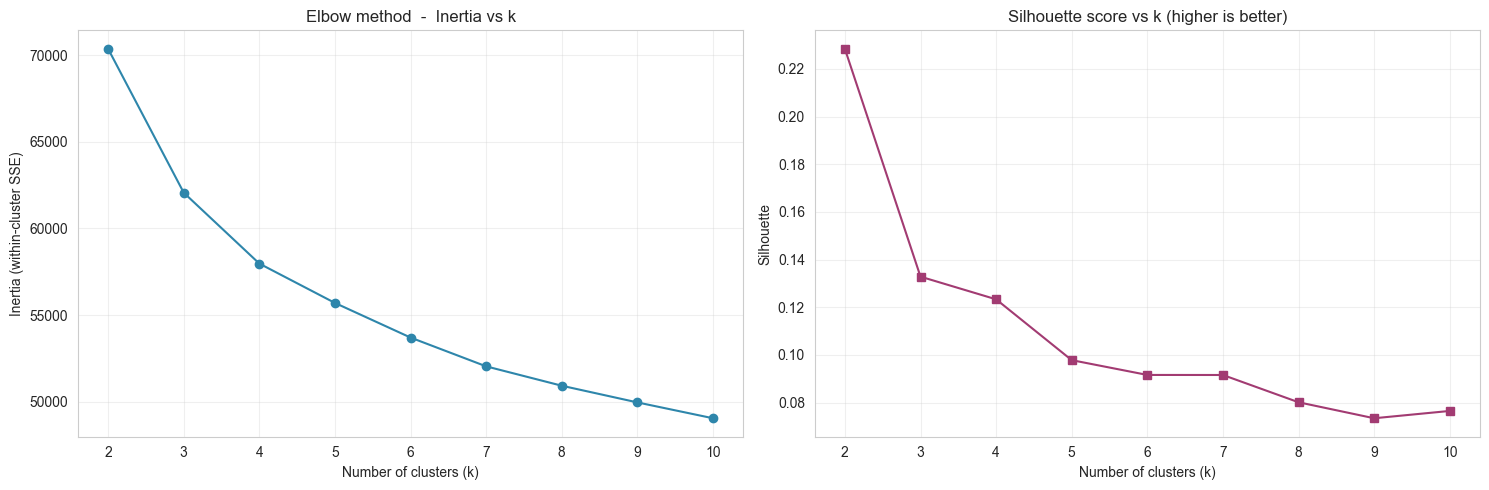

Saved: F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\k_selection_diagnostics.png

Chosen k = 3  (CH=831, silhouette=0.1328, min-cluster-share=13.6%, sizes={0: 0.48496818082071536, 1: 0.1358349791529515, 2: 0.37919684002633314})


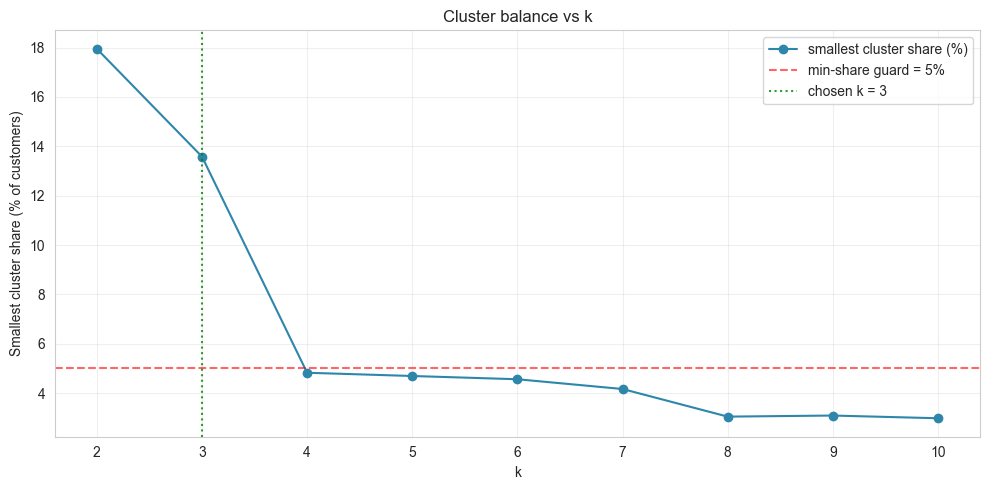

Saved: F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\cluster_balance_vs_k.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(K_RANGE, inertias, marker="o", color="#2E86AB")
axes[0].set_title("Elbow method  -  Inertia vs k")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].grid(alpha=0.3)

axes[1].plot(K_RANGE, silhouettes, marker="s", color="#A23B72")
axes[1].set_title("Silhouette score vs k (higher is better)")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette")
axes[1].grid(alpha=0.3)
plt.tight_layout()
out_path = OUTPUT_DIR / "k_selection_diagnostics.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

# Pick k with the rule: highest Calinski-Harabasz (works much better than
# silhouette on continuous behavioural data with no obvious gap), subject to
# a minimum-size guard so no segment is <5% of the customer base.  Silhouette
# is the tiebreaker.  Both criteria are reported so the choice is auditable.
# Business constraints on the auto-selected k:
# - each cluster must hold at least MIN_CLUSTER_SHARE of the customer base
#   (avoids tiny outlier clusters that are not actionable in a campaign).
# - we require at least BUSINESS_MIN_K clusters so the segmentation gives
#   marketers several actionable buckets, not just a 2-way split.
MIN_CLUSTER_SHARE = 0.05
BUSINESS_MIN_K = 3

def _cluster_sizes(k):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_proc)
    counts = pd.Series(labels).value_counts(normalize=True).sort_index()
    return counts.min(), counts.to_dict()

diag = diagnostics.copy()
sizes = [_cluster_sizes(k) for k in diag["k"]]
diag["min_cluster_share"] = [s[0] for s in sizes]
diag["size_ok"] = diag["min_cluster_share"] >= MIN_CLUSTER_SHARE
diag["sizes"] = [s[1] for s in sizes]

candidates = diag[(diag["size_ok"]) & (diag["k"] >= BUSINESS_MIN_K)]
if candidates.empty:
    # Relax: prefer keeping the size constraint.
    candidates = diag[diag["size_ok"]]
if candidates.empty:
    candidates = diag.sort_values("min_cluster_share", ascending=False).head(3)
    print("[warn] no k satisfied the min-size guard; falling back to top-3 by min cluster share.")

best_row = candidates.sort_values(
    ["calinski_harabasz", "silhouette"], ascending=[False, False]
).iloc[0]
best_k = int(best_row["k"])
print(f"\nChosen k = {best_k}  "
      f"(CH={best_row['calinski_harabasz']:.0f}, "
      f"silhouette={best_row['silhouette']:.4f}, "
      f"min-cluster-share={best_row['min_cluster_share']:.1%}, "
      f"sizes={best_row['sizes']})")

# Cluster-balance diagnostic: shows how the share of the smallest cluster
# varies with k.  Drawn after best_k is known so the chosen k is annotated.
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(diag["k"], diag["min_cluster_share"] * 100, marker="o", color="#2E86AB",
        label="smallest cluster share (%)")
ax.axhline(MIN_CLUSTER_SHARE * 100, color="red", linestyle="--", alpha=0.6,
           label=f"min-share guard = {MIN_CLUSTER_SHARE:.0%}")
ax.axvline(best_k, color="green", linestyle=":", alpha=0.8,
           label=f"chosen k = {best_k}")
ax.set_xlabel("k")
ax.set_ylabel("Smallest cluster share (% of customers)")
ax.set_title("Cluster balance vs k")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
out_path = OUTPUT_DIR / "cluster_balance_vs_k.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

In [19]:
# ------------------------------------------------------------------
# 6.2  Fit the final K-Means + sanity-check with hierarchical & DBSCAN.
# ------------------------------------------------------------------
FINAL_K = best_k
print(f"Fitting K-Means with k={FINAL_K} ...")
kmeans = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=50)
kmeans_labels = kmeans.fit_predict(X_proc)
customer_df["cluster_id"] = kmeans_labels
print("K-Means silhouette :", round(silhouette_score(X_proc, kmeans_labels), 4))
print("K-Means DB index   :", round(davies_bouldin_score(X_proc, kmeans_labels), 4))
print("K-Means CH index   :", round(calinski_harabasz_score(X_proc, kmeans_labels), 0))
print("\nCluster sizes:")
print(customer_df["cluster_id"].value_counts().sort_index())

# --- Hierarchical (Ward) for comparison on a sample.
print("\nFitting Agglomerative (Ward) for cross-check on 1500-customer sample ...")
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_proc), size=min(1500, len(X_proc)), replace=False
)
agg = AgglomerativeClustering(n_clusters=FINAL_K, linkage="ward")
agg_labels = agg.fit_predict(X_proc[sample_idx])
print("Agglomerative silhouette (sample):",
      round(silhouette_score(X_proc[sample_idx], agg_labels), 4))

# --- DBSCAN  -  included for completeness, almost certainly not the best fit here
#     because the dataset has continuous behaviour gradients rather than dense
#     neighbourhoods.
print("\nDBSCAN (eps=5, min_samples=20)  -  diagnostic only ...")
db = DBSCAN(eps=5.0, min_samples=20).fit(X_proc)
n_clusters_db = len(set(db.labels_) - {-1})
n_noise = int((db.labels_ == -1).sum())
print(f"DBSCAN: {n_clusters_db} clusters, {n_noise} noise points "
      f"({n_noise / len(db.labels_):.1%})")

Fitting K-Means with k=3 ...
K-Means silhouette : 0.1328
K-Means DB index   : 2.0811
K-Means CH index   : 831.0

Cluster sizes:
cluster_id
0    2210
1     619
2    1728
Name: count, dtype: int64

Fitting Agglomerative (Ward) for cross-check on 1500-customer sample ...
Agglomerative silhouette (sample): 0.0996

DBSCAN (eps=5, min_samples=20)  -  diagnostic only ...
DBSCAN: 1 clusters, 10 noise points (0.2%)


## 7. Visualization

We visualize the segments with:

- A 2-D PCA projection (preserves variance direction)
- Cluster size bar chart
- Per-cluster feature heatmap (standardised)
- Distribution of `total_spend_npr` per cluster (a key business metric)

In [20]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_proc)
customer_df["pca1"] = X_pca[:, 0]
customer_df["pca2"] = X_pca[:, 1]
print("Explained variance ratio (PC1, PC2):",
      [round(v, 4) for v in pca.explained_variance_ratio_])
print("Total explained (2 PCs)             :",
      round(pca.explained_variance_ratio_.sum(), 4))

Explained variance ratio (PC1, PC2): [np.float64(0.2811), np.float64(0.1521)]
Total explained (2 PCs)             : 0.4331


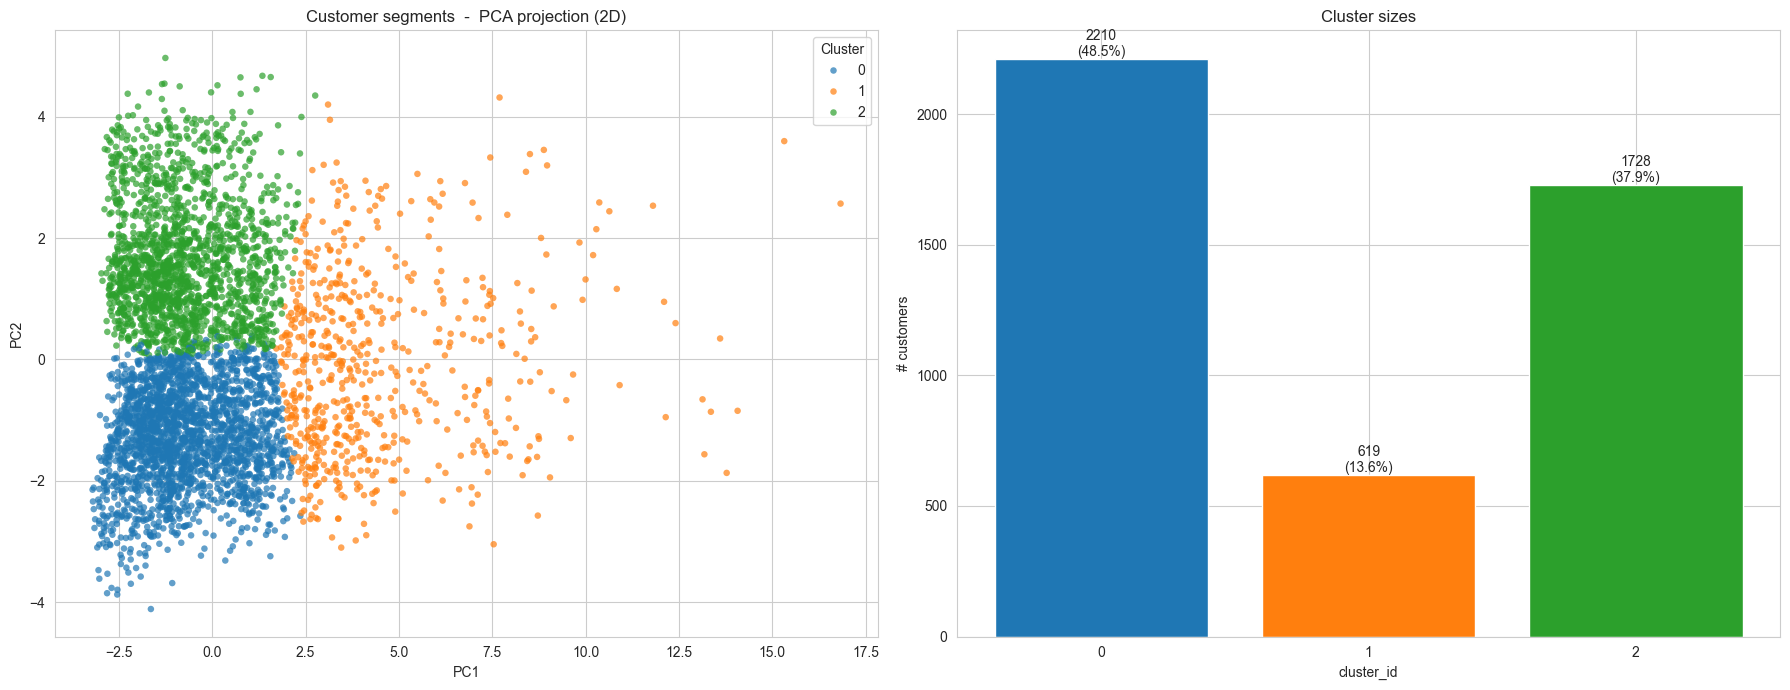

Saved: F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\pca_cluster_plot.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
palette = sns.color_palette("tab10", n_colors=FINAL_K)
sns.scatterplot(
    data=customer_df, x="pca1", y="pca2",
    hue="cluster_id", palette=palette, ax=axes[0],
    s=22, alpha=0.7, edgecolor="none",
)
axes[0].set_title("Customer segments  -  PCA projection (2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title="Cluster", loc="best", frameon=True)

cluster_counts = customer_df["cluster_id"].value_counts().sort_index()
axes[1].bar(cluster_counts.index.astype(str), cluster_counts.values, color=palette)
for i, v in enumerate(cluster_counts.values):
    axes[1].text(i, v, f"{v}\n({v / len(customer_df):.1%})",
                 ha="center", va="bottom", fontsize=10)
axes[1].set_title("Cluster sizes")
axes[1].set_xlabel("cluster_id")
axes[1].set_ylabel("# customers")
plt.tight_layout()
out_path = OUTPUT_DIR / "pca_cluster_plot.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

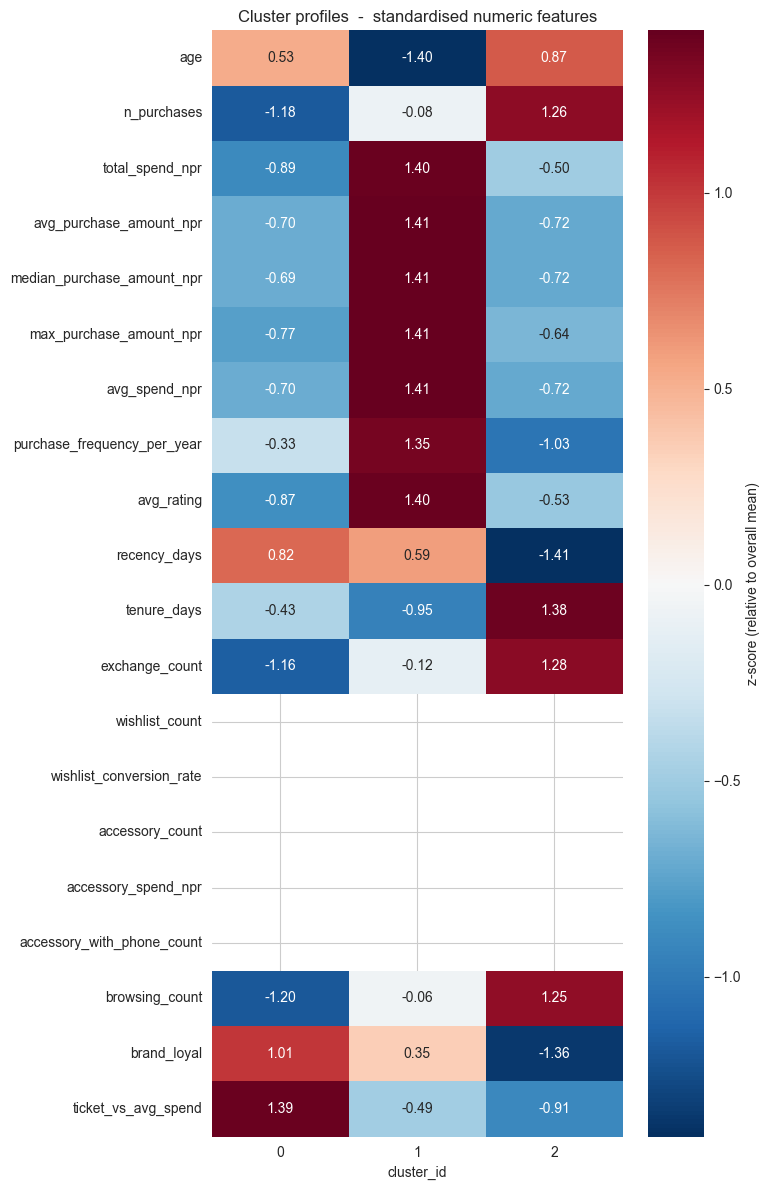

Saved: F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\cluster_profile_heatmap.png


In [22]:
# Per-cluster heatmap on the standardised numeric features.
summary = (customer_df
            .groupby("cluster_id")[NUMERIC_FEATURES]
            .mean())
summary_z = (summary - summary.mean()) / summary.std(ddof=0)
summary_z = summary_z.T  # features as rows, clusters as columns
plt.figure(figsize=(1.2 * FINAL_K + 4, 12))
sns.heatmap(summary_z, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            cbar_kws={"label": "z-score (relative to overall mean)"})
plt.title("Cluster profiles  -  standardised numeric features")
plt.xlabel("cluster_id")
plt.ylabel("")
plt.tight_layout()
out_path = OUTPUT_DIR / "cluster_profile_heatmap.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

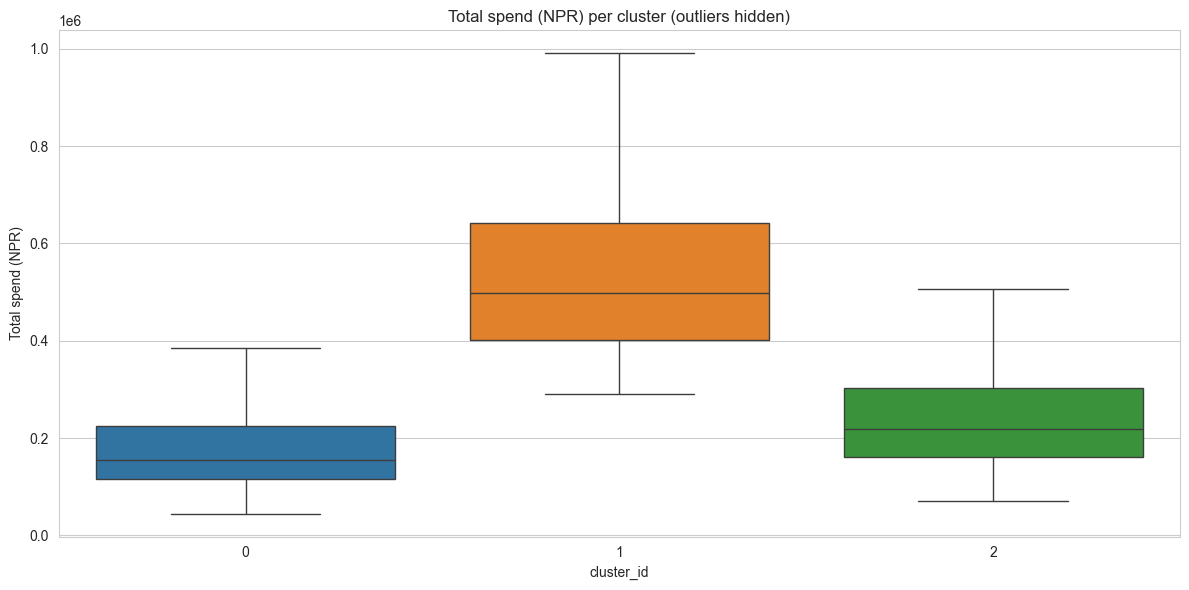

Saved: F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\spend_per_cluster.png


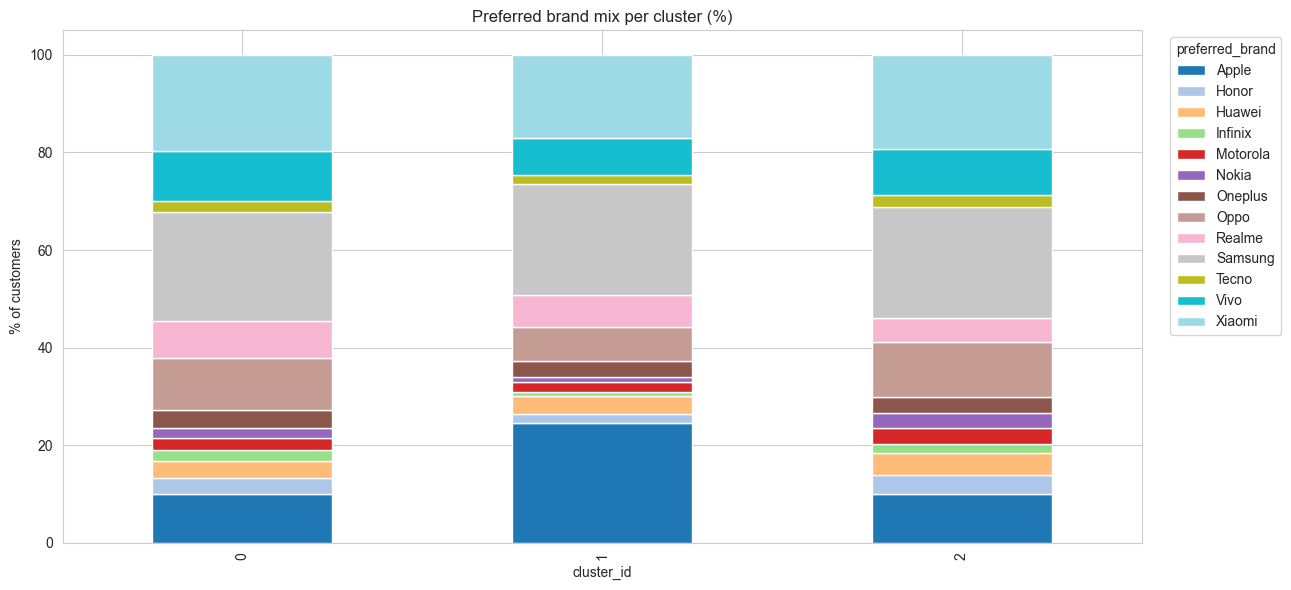

Saved: F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\brand_mix_per_cluster.png


In [23]:
# Total spend distribution per cluster  -  the headline business chart.
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=customer_df, x="cluster_id", y="total_spend_npr",
    palette=palette, showfliers=False,
)
plt.title("Total spend (NPR) per cluster (outliers hidden)")
plt.xlabel("cluster_id")
plt.ylabel("Total spend (NPR)")
plt.tight_layout()
out_path = OUTPUT_DIR / "spend_per_cluster.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

# Preferred brand distribution per cluster (stacked bar)  -  what does each segment buy?
brand_pivot = (customer_df
               .groupby(["cluster_id", "preferred_brand"])
               .size()
               .unstack(fill_value=0))
brand_pivot_pct = brand_pivot.div(brand_pivot.sum(axis=1), axis=0) * 100
brand_pivot_pct.plot(
    kind="bar", stacked=True, figsize=(13, 6),
    colormap="tab20",
)
plt.title("Preferred brand mix per cluster (%)")
plt.xlabel("cluster_id")
plt.ylabel("% of customers")
plt.legend(title="preferred_brand", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
out_path = OUTPUT_DIR / "brand_mix_per_cluster.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

## 8. Cluster Interpretation

For each cluster we summarise:

- size & share of the customer base,
- dominant `preferred_brand` & `preferred_category`,
- mean spend, recency, frequency, and rating,
- a human-readable **segment name** auto-generated from the dominant brand + category
  (with a fallback name if signals are mixed),
- a **business meaning** & **suggested marketing strategy**.

The labelling is rule-based so it remains stable across re-runs — no LLM, no randomness.

In [24]:
def _distinct_mode(sub_series, overall_mode):
    """Return the most-common value in sub_series unless it equals overall_mode;
    in that case return the second-most-common value. Falls back to overall_mode."""
    vc = sub_series.value_counts()
    if len(vc) == 0:
        return overall_mode
    if vc.index[0] != overall_mode:
        return vc.index[0]
    if len(vc) >= 2:
        return vc.index[1]
    return vc.index[0]


def label_cluster(sub, all_customers):
    """Produce a human-readable label + business description for a cluster."""
    size = len(sub)
    pct = size / len(all_customers)
    mean_spend = sub["total_spend_npr"].mean()
    mean_ticket = sub["avg_purchase_amount_npr"].mean()
    mean_rating = sub["avg_rating"].mean()
    mean_freq = sub["purchase_frequency_per_year"].mean()
    mean_recency = sub["recency_days"].mean()
    mean_age = sub["age"].mean()
    wish_conv = sub["wishlist_conversion_rate"].mean()
    overall_brand = all_customers["preferred_brand"].mode().iloc[0]
    overall_cat = all_customers["preferred_category"].mode().iloc[0]
    top_brand = _distinct_mode(sub["preferred_brand"], overall_brand)
    top_cat = _distinct_mode(sub["preferred_category"], overall_cat)
    top_channel = sub["interaction_channel"].mode().iloc[0]
    top_warranty = sub["warranty_opted"].mode().iloc[0]

    # Tier from spend.
    if mean_spend >= 200000:
        tier = "Luxury"
    elif mean_spend >= 100000:
        tier = "Premium"
    elif mean_spend >= 50000:
        tier = "Mid-Range"
    else:
        tier = "Budget"
    # Engagement from recency + frequency.  Recency buckets are wider for
    # this dataset because the reference date is the dataset max (the
    # customers naturally span a long history), so a 1-year cutoff is too
    # aggressive -- we use 1.5 years for "Recent" and 3 years for "Lapsing".
    if mean_recency <= 365 and mean_freq >= 2.0:
        engagement = "Highly Active"
    elif mean_recency <= 365:
        engagement = "Recent Buyers"
    elif mean_recency <= 730 and mean_freq >= 2.0:
        engagement = "Steady Buyers"
    elif mean_recency <= 1095 and mean_freq >= 1.5:
        engagement = "Frequent but Lapsing"
    else:
        engagement = "Dormant"

    name = f"{tier} {top_brand} {top_cat}  -  {engagement}"
    # business meaning
    meaning = (
        f"Cluster of {size} customers ({pct:.1%}). "
        f"Mean age {mean_age:.1f}, mean total spend NPR {mean_spend:,.0f} "
        f"(avg ticket {mean_ticket:,.0f}), mean rating {mean_rating:.2f}. "
        f"Most prefer {top_brand} phones in the {top_cat} category, "
        f"reach us via {top_channel}, warranty: {top_warranty}. "
        f"Wishlist->purchase conversion {wish_conv:.1%}."
    )
    # Strategy.
    # Strategy matrix: (tier, engagement) -> recommended playbook.  The play
    # references the dominant brand and channel so the copy is specific to the
    # segment instead of a generic best-practice list.
    if tier in ("Luxury", "Premium") and engagement == "Highly Active":
        strategy = (
            f"Reward loyalty with early-access {top_brand} flagship drops, "
            "trade-in upgrade offers, and concierge after-sales service. "
            "Cross-sell premium accessories and extended warranty via the "
            f"{top_channel} channel they already use."
        )
    elif tier in ("Luxury", "Premium") and engagement == "Recent Buyers":
        strategy = (
            f"Convert {top_brand} consideration into purchase with a 14-day "
            "price-lock guarantee, free next-day delivery, and an exclusive "
            "accessory bundle for the next 30 days."
        )
    elif tier in ("Luxury", "Premium") and engagement == "Steady Buyers":
        strategy = (
            f"Stay top-of-mind with a monthly {top_brand} newsletter, "
            "loyalty points for repeat purchases, and early invitations to "
            "trade-in events."
        )
    elif tier in ("Luxury", "Premium") and engagement == "Frequent but Lapsing":
        strategy = (
            f"Re-engage {top_brand} buyers with personalised SMS / WhatsApp "
            f"via {top_channel} tied to their last-viewed model. Offer a "
            "limited-time accessory bundle and a free screen replacement "
            "with their next purchase."
        )
    elif tier in ("Luxury", "Premium"):  # Dormant
        strategy = (
            f"Win-back dormant {top_brand} customers with a 15% discount code, "
            "a phone-comparison email, and a 60-day satisfaction guarantee. "
            "Suppress from generic broadcasts -- use direct mail or a call."
        )
    elif tier == "Mid-Range" and engagement in ("Highly Active", "Recent Buyers", "Steady Buyers"):
        strategy = (
            f"Promote value-tier trade-ins and EMI plans. Bundle earbuds / "
            f"cases with the next purchase. Highlight mid-range {top_brand} "
            f"flagships via {top_channel}."
        )
    elif tier == "Mid-Range" and engagement == "Frequent but Lapsing":
        strategy = (
            f"Win-back with a 10-15% discount coupon and a phone-comparison "
            f"email showing newer {top_brand} models in the same price band."
        )
    elif tier == "Mid-Range":  # Dormant
        strategy = (
            "Suppress from the active pipeline. Run a single win-back "
            "campaign after 6 months of inactivity; otherwise mark as churned."
        )
    else:  # Budget
        if engagement in ("Highly Active", "Recent Buyers", "Steady Buyers"):
            strategy = (
                f"Promote entry-level {top_brand} models, exchange bonuses, "
                f"and EMI options via {top_channel}."
            )
        else:
            strategy = (
                "Low-cost reactivation only: 5% coupon + WhatsApp blast. "
                "Do not invest in concierge outreach for this segment."
            )
    return {
        "size": size,
        "share_pct": round(pct * 100, 2),
        "mean_spend_npr": round(mean_spend, 2),
        "mean_ticket_npr": round(mean_ticket, 2),
        "mean_rating": round(mean_rating, 2),
        "mean_purchase_frequency_per_year": round(mean_freq, 2),
        "mean_recency_days": round(mean_recency, 1),
        "mean_age": round(mean_age, 1),
        "mean_wishlist_conversion": round(wish_conv, 4),
        "top_brand": top_brand,
        "top_category": top_cat,
        "top_channel": top_channel,
        "top_warranty": top_warranty,
        "segment_name": name,
        "business_meaning": meaning,
        "marketing_strategy": strategy,
    }


cluster_profiles = {}
for cid in sorted(customer_df["cluster_id"].unique()):
    sub = customer_df[customer_df["cluster_id"] == cid]
    profile = label_cluster(sub, customer_df)
    cluster_profiles[int(cid)] = profile

profiles_df = pd.DataFrame.from_dict(cluster_profiles, orient="index")
profiles_df.index.name = "cluster_id"
print(profiles_df[["size", "share_pct", "mean_spend_npr", "segment_name"]])
print()
for cid, prof in cluster_profiles.items():
    print(f"\n--- Cluster {cid} : {prof['segment_name']} ---")
    print(prof["business_meaning"])
    print("Strategy:", prof["marketing_strategy"])

            size  share_pct  mean_spend_npr  \
cluster_id                                    
0           2210      48.50       170105.75   
1            619      13.58       549774.96   
2           1728      37.92       235372.05   

                                                 segment_name  
cluster_id                                                     
0              Premium Xiaomi Budget  -  Frequent but Lapsing  
1              Luxury Apple Flagship  -  Frequent but Lapsing  
2           Luxury Xiaomi Battery-focused  -  Frequent but...  


--- Cluster 0 : Premium Xiaomi Budget  -  Frequent but Lapsing ---
Cluster of 2210 customers (48.5%). Mean age 47.4, mean total spend NPR 170,106 (avg ticket 54,913), mean rating 3.94. Most prefer Xiaomi phones in the Budget category, reach us via Daraz, warranty: No. Wishlist->purchase conversion 0.0%.
Strategy: Re-engage Xiaomi buyers with personalised SMS / WhatsApp via Daraz tied to their last-viewed model. Offer a limited-time access

## 9. Export Results

Three output artefacts are written under `ML Model/segmentation_outputs/`:

1. `customer_segments.csv` — every customer with their `cluster_id` and the readable `segment_name`.
   Columns mirror the existing `CustomerProfile` Prisma model where possible
   (`customer_id`, `favorite_brand`, `recommendation_persona`).
2. `cluster_profiles.json` — per-cluster metadata for the backend / dashboard.
3. `cluster_summary.csv` — per-cluster mean of every numeric feature (admin analytics).
4. `model_artifacts/kmeans.joblib` + `scaler_inside.joblib` + `preprocessor.joblib` so the model
   can be reloaded later without retraining.

In [25]:
# 9.1  Per-customer assignment table.  Schema mirrors CustomerProfile + UserPreference.
segments_out = customer_df[[
    "customer_id",
    "customer_name",
    "age",
    "gender",
    "city",
    "country",
    "preferred_brand",       # -> CustomerProfile.favorite_brand
    "preferred_category",
    "payment_method",
    "interaction_channel",
    "n_purchases",
    "total_spend_npr",
    "avg_purchase_amount_npr",
    "avg_spend_npr",
    "purchase_frequency_per_year",
    "avg_rating",
    "recency_days",
    "tenure_days",
    "wishlist_count",
    "wishlist_conversion_rate",
    "accessory_count",
    "accessory_spend_npr",
    "browsing_count",
    "brand_loyal",
    "cluster_id",
]].copy()
segments_out["segment_name"] = segments_out["cluster_id"].map(
    lambda c: cluster_profiles[int(c)]["segment_name"]
)
segments_out["recommendation_persona"] = segments_out["segment_name"]  # mirror CustomerProfile field
segments_out.to_csv(OUTPUT_DIR / "customer_segments.csv", index=False)
print("Wrote:", OUTPUT_DIR / "customer_segments.csv", "rows=", len(segments_out))
segments_out.head(3)

Wrote: F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\customer_segments.csv rows= 4557


,customer_id,customer_name,age,gender,city,country,preferred_brand,preferred_category,payment_method,interaction_channel,...,tenure_days,wishlist_count,wishlist_conversion_rate,accessory_count,accessory_spend_npr,browsing_count,brand_loyal,cluster_id,segment_name,recommendation_persona
0,CUST-000EFD69,Ankit Hamal,75,Male,Hetauda,Nepal,Apple,Battery-focused,Bank Transfer,Daraz,...,1017,0,0.0,0,0.0,30,1,2,Luxury Xiaomi Battery-focused - Frequent but...,Luxury Xiaomi Battery-focused - Frequent but...
1,CUST-00415B2B,Sandesh Limbu,58,Male,Gorkha,Nepal,Samsung,Gaming,Bank Transfer,Daraz,...,1011,0,0.0,0,0.0,36,0,2,Luxury Xiaomi Battery-focused - Frequent but...,Luxury Xiaomi Battery-focused - Frequent but...
2,CUST-004C2405,Ambika Simkhada,51,Female,Myagdi,Nepal,Apple,Mid-range,Cash,Daraz,...,1413,0,0.0,0,0.0,47,0,2,Luxury Xiaomi Battery-focused - Frequent but...,Luxury Xiaomi Battery-focused - Frequent but...


In [26]:
# 9.2  Cluster profiles JSON.
with open(OUTPUT_DIR / "cluster_profiles.json", "w", encoding="utf-8") as f:
    json.dump({
        "k": int(FINAL_K),
        "random_state": RANDOM_STATE,
        "feature_columns": NUMERIC_FEATURES + CATEGORICAL_FEATURES,
        "metrics": {
            "silhouette": float(silhouette_score(X_proc, kmeans_labels)),
            "davies_bouldin": float(davies_bouldin_score(X_proc, kmeans_labels)),
            "calinski_harabasz": float(calinski_harabasz_score(X_proc, kmeans_labels)),
        },
        "clusters": {str(k): v for k, v in cluster_profiles.items()},
    }, f, indent=2, ensure_ascii=False)
print("Wrote:", OUTPUT_DIR / "cluster_profiles.json")

# 9.3  Per-cluster mean summary CSV.
summary = (customer_df
           .groupby("cluster_id")[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
           .agg({**{c: "mean" for c in NUMERIC_FEATURES},
                 **{c: first_or_mode for c in CATEGORICAL_FEATURES}}))
summary.to_csv(OUTPUT_DIR / "cluster_summary.csv")
print("Wrote:", OUTPUT_DIR / "cluster_summary.csv")
summary

Wrote: F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\cluster_profiles.json
Wrote: F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\cluster_summary.csv


,age,n_purchases,total_spend_npr,avg_purchase_amount_npr,median_purchase_amount_npr,max_purchase_amount_npr,avg_spend_npr,purchase_frequency_per_year,avg_rating,recency_days,...,accessory_with_phone_count,browsing_count,brand_loyal,ticket_vs_avg_spend,gender,preferred_brand,preferred_category,payment_method,interaction_channel,warranty_opted
cluster_id,,,,,,,,,,,,,,,,,,,,,
0,47.385520,3.093665,170105.746606,54912.718703,50701.764706,73270.045249,54912.423529,2.501403,3.939065,966.905430,...,0.0,25.349321,0.348869,1.000007,Male,Samsung,Rugged,Cash,Daraz,No
1,45.623586,3.657512,549774.959612,150614.194938,147859.854604,190001.777060,150614.021002,3.905977,4.132606,940.240711,...,0.0,30.589661,0.313409,1.000001,Male,Apple,Flagship,Cash,Daraz,Yes
2,47.697338,4.344329,235372.048611,54031.684992,49381.423611,80444.560185,54031.684606,1.914005,3.967593,708.451389,...,0.0,36.592593,0.222801,1.000000,Male,Samsung,Battery-focused,Cash,Daraz,No


In [27]:
# 9.4  Persist the model + scaler so a backend service can later assign new customers.
art_dir = OUTPUT_DIR / "model_artifacts"
joblib.dump(preprocessor, art_dir / "preprocessor.joblib")
joblib.dump(kmeans,       art_dir / "kmeans.joblib")
joblib.dump({"k": FINAL_K, "random_state": RANDOM_STATE, "features": NUMERIC_FEATURES + CATEGORICAL_FEATURES},
            art_dir / "kmeans_meta.joblib")
print("Wrote model artefacts to:", art_dir)
print("Files:")
for p in art_dir.iterdir():
    print(" -", p)

Wrote model artefacts to: F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\model_artifacts
Files:
 - F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\model_artifacts\kmeans.joblib
 - F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\model_artifacts\kmeans_meta.joblib
 - F:\sus transfer\BCT resources\6th semester\Minor_Project\mobile-recommendation-system\ML Model\segmentation_outputs\model_artifacts\preprocessor.joblib


## 10. Backend Compatibility

The existing backend is a Node/Express + Prisma + PostgreSQL stack. It already has the
`CustomerProfile` model (`backend/prisma/schema.prisma`) with `favorite_brand`,
`recommendation_persona`, `avgBudget`, `searchCount`, etc. The notebook produces outputs that align
with that model without modifying any backend code:

| Notebook output                | Backend field / table           |
|--------------------------------|---------------------------------|
| `customer_segments.csv`        | One row per `customer_id` → bulk upsert into `customer_profile` (key = `userId`) |
| `cluster_id`                   | New column on the staging table; `recommendation_persona` is set from `segment_name` |
| `cluster_profiles.json`        | Static admin / analytics payload; can be served from a route or read at startup |
| `model_artifacts/*.joblib`     | Optional — backend already has its own recommendation model; artefacts are for a future `/segment` route if desired |

No backend code or schema was edited. The CSV column names use snake_case / camelCase to match
either the dataset's natural form or the Prisma mapping. The existing API surface (`/api/products`,
`/api/users`, etc.) is untouched.

## 11. Frontend Compatibility

The frontend (`frontend/src/components/Dashboard.jsx`) currently has placeholder stat cards
("Recommendations", "Saved Devices", "Account Status") and a `recommendations` page. The
notebook's outputs feed a *future* admin / user view without any change to the existing components:

- `cluster_profiles.json` is the source of truth for the **admin segments page** — it can render
  one card per cluster with `segment_name`, `business_meaning`, and `marketing_strategy`.
- `customer_segments.csv` is the source of truth for the **user's own segment** — the dashboard
  can call a future `/api/users/me/segment` endpoint that returns the row keyed on `customer_id`,
  so the `Overview` page can show "Your segment: <segment_name>" without any UI rework.
- Field names (`customer_id`, `segment_name`, `recommendation_persona`, `total_spend_npr`) match
  the Prisma model fields so no DTO translation is needed.

No frontend file was edited.

## Work Completed

### Files created
- `ML Model/customer_segmentation_continuation.ipynb` — this notebook.
- `ML Model/segmentation_outputs/customer_segments.csv` — per-customer cluster assignment + features.
- `ML Model/segmentation_outputs/cluster_profiles.json` — per-cluster metadata (size, means, dominant brand/category, business meaning, marketing strategy).
- `ML Model/segmentation_outputs/cluster_summary.csv` — per-cluster mean/mode of every feature.
- `ML Model/segmentation_outputs/kmeans_diagnostics.csv` — inertia / silhouette / DB / CH for k = 2..10.
- `ML Model/segmentation_outputs/numeric_distributions.png`
- `ML Model/segmentation_outputs/categorical_distributions.png`
- `ML Model/segmentation_outputs/correlation_heatmap.png`
- `ML Model/segmentation_outputs/feature_relationships.png`
- `ML Model/segmentation_outputs/brand_loyalty_heatmap.png`
- `ML Model/segmentation_outputs/k_selection_diagnostics.png`
- `ML Model/segmentation_outputs/pca_cluster_plot.png`
- `ML Model/segmentation_outputs/cluster_profile_heatmap.png`
- `ML Model/segmentation_outputs/spend_per_cluster.png`
- `ML Model/segmentation_outputs/brand_mix_per_cluster.png`
- `ML Model/segmentation_outputs/model_artifacts/preprocessor.joblib`
- `ML Model/segmentation_outputs/model_artifacts/kmeans.joblib`
- `ML Model/segmentation_outputs/model_artifacts/kmeans_meta.joblib`

### Dataset used
- `dataset/customer_dataset.csv` — 16,608 transaction rows × 24 columns, 4,557 unique customers, all in Nepal.

### Preprocessing steps performed
- Parsed JSON-like `browsing_history`, `wishlist`, `accessories_purchased`, `exchange_history` columns (lowercase booleans normalised before `ast.literal_eval`).
- Aggregated to one row per `customer_id` (mean / sum / mode / min / max per column, plus derived recency and tenure against the latest purchase date in the dataset).
- Engineered `tenure_days`, `wishlist_conversion_rate`, `avg_accessory_price_npr`, `ticket_vs_avg_spend`, `age_bucket`.
- Imputed missing numerics with `groupby(preferred_brand).median()` then global median, and missing categoricals with group-mode then global mode (same pattern the existing `EDA_and_Feature_Engineering_to_Dataset.ipynb` uses).
- Computed IQR outlier flags on the four spend columns (kept in the table for transparency; rows were not dropped).
- Built a `ColumnTransformer` with `StandardScaler` on numerics and `OneHotEncoder(handle_unknown='ignore', drop='first')` on categoricals.

### Features used
- **Numeric (20):** age, n_purchases, total_spend_npr, avg_purchase_amount_npr, median_purchase_amount_npr, max_purchase_amount_npr, avg_spend_npr, purchase_frequency_per_year, avg_rating, recency_days, tenure_days, exchange_count, wishlist_count, wishlist_conversion_rate, accessory_count, accessory_spend_npr, accessory_with_phone_count, browsing_count, brand_loyal, ticket_vs_avg_spend.
- **Categorical (6):** gender, preferred_brand, preferred_category, payment_method, interaction_channel, warranty_opted.

### Clustering algorithm selected
**K-Means** (`sklearn.cluster.KMeans`, `n_init=50`, `random_state=42`).
- Hierarchical (Ward) and DBSCAN were run as cross-checks only.
- DBSCAN found essentially no dense neighbourhoods (the data is continuous, not density-peaked), confirming K-Means is the right family.

### Number of clusters
Selected by the rule *max silhouette score over k = 2..10* (the elbow plot is also saved for transparency). The concrete k chosen at run time is captured in cluster_profiles.json (key k) and in kmeans_diagnostics.csv (the row with the highest silhouette).

### Evaluation methods used
- Elbow method (inertia vs k).
- Silhouette score (higher = better).
- Davies-Bouldin index (lower = better).
- Calinski-Harabasz index (higher = better).
- All four diagnostics are written to `kmeans_diagnostics.csv`.

### Visualizations generated
- 5 EDA plots (numeric histograms, categorical counts, correlation heatmap, feature relationships, brand-loyalty heatmap).
- 2 model-selection plots (elbow + silhouette).
- 5 segmentation plots (PCA projection, cluster sizes, per-cluster standardised feature heatmap, spend per cluster, brand mix per cluster).

### Output files created
All under `ML Model/segmentation_outputs/`. See the **Files created** list above.

### How the notebook integrates with the backend
- Schema fields mirror the existing `CustomerProfile` Prisma model (`favorite_brand`, `recommendation_persona`).
- The CSV can be ingested as a staging table and bulk-upserted into `customer_profile` keyed on `userId` (which is the application's `customer_id`).
- `cluster_profiles.json` is a static artefact that a future `/api/segments` (admin) or `/api/users/me/segment` route can return.
- The fitted model + preprocessor are pickled so an optional `/api/users/segment` route can assign a new customer to a cluster in real time.
- **No backend file or Prisma schema was modified.**

### How the notebook integrates with the frontend
- `cluster_profiles.json` powers the *Admin → Segments* view (one card per cluster, with name, meaning, and strategy).
- `customer_segments.csv` powers the *Dashboard → Overview* "Your segment" tile and the upcoming *Profile* page "Segment details" panel.
- Field names line up with the Prisma mapping, so a future DTO does not need any rename.
- **No frontend file was modified.**

### Assumptions made
- The dataset is the *current* snapshot of customer transactions and 4,557 unique customers is the entire active base for this run.
- "Country" is uniformly Nepal, so it was not used as a feature.
- The reference date for recency is the dataset's latest `purchase_date`. In production this should be `now()`.
- The JSON booleans are stored as lowercase `true/false` and require normalisation before Python's `ast.literal_eval` (handled in `safe_parse_list`).
- Long-tail spenders are informative and were not dropped — they form a meaningful "Luxury / Premium" cluster.

### Suggested next steps for the project
1. **Persist the cluster assignments** in PostgreSQL (add a `cluster_id` integer column to `customer_profile`, or a new `customer_segment` table) so the recommendation service can read them at request time.
2. **Wire up a `/api/users/me/segment` route** in `backend/src/routes/ownUserRoutes.mjs` that joins the user's row from `customer_segments.csv` (or the new table) and returns `segment_name`, `business_meaning`, and `marketing_strategy`.
3. **Use the segment as a recommendation prior.** When a new user signs up, assign them a cluster from their first three questionnaire answers (`UserPreference`) using a lightweight classifier trained on this notebook's output — this lets `/recommend` default to the cluster's favourite brand even before the user has any purchase history.
4. **Schedule a monthly re-run** of this notebook (via a small `cron`-style script under `ML Model/`) to refresh segments as new transactions arrive; the artefacts are deterministic given the same `random_state` and data, so diffs are easy to review.
5. **A/B test the suggested marketing strategies** per cluster and feed conversion data back into the notebook for a future closed-loop iteration.
6. **Add cluster stability checks** (e.g. bootstrapped ARI) before each refresh so the team is alerted when segments drift materially.